In [ ]:
####### IMPORTS #########
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.base import clone

  External ID Participant ID  week_num       diagnosis   fecalcal  \
0    CSM5FZ3N          C3001       0.0  Crohns Disease  193.89000   
1    CSM5FZ4C          C3001       8.0  Crohns Disease   61.34000   
2    CSM5MCVV          C3001      16.0  Crohns Disease  115.27000   
3    CSM67UA2          C3001      28.0  Crohns Disease   23.20350   
4    CSM79HGP          C3001      38.0  Crohns Disease   37.17836   

   Bacteroides vulgatus  Bacteroides uniformis  Bacteroides thetaiotaomicron  \
0              42.34520               31.29744                       6.81155   
1              12.29822               28.74672                      26.46909   
2              12.38214               15.91063                       3.77383   
3              36.69818               28.04901                      16.81345   
4              33.26674               36.24943                       7.88757   

   Faecalibacterium prausnitzii  Roseburia faecis  ...  Prevotella histicola  \
0                       

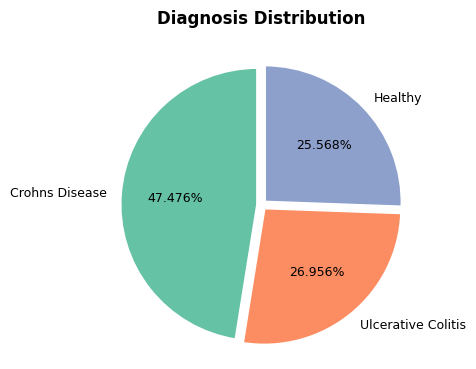

In [2]:
########### LOAD THE DATASET ###########
data = pd.read_csv('hmp2_ibd_metagenomics_atlas_20260219_121629.csv')

print(data.head(5))
print(data.shape)
print('distribution of diagnosis:')
print((data['diagnosis'].value_counts(normalize=True) * 100).map(lambda x: f'{x:.3f}%'))

#plot a pie chart
counts = data["diagnosis"].value_counts(normalize=True)*100

colors = ["#66c2a5", "#fc8d62", "#8da0cb"]

plt.figure(figsize=(4, 4))

plt.pie(
    counts,
    labels=counts.index,
    colors=colors,
    autopct="%1.3f%%",
    startangle=90,
    explode=[0.03, 0.03, 0.03],
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 9
    }
)

plt.title(
    "Diagnosis Distribution",
    fontsize=12,
    fontweight="bold",
    pad=20
)

plt.axis("equal")

#plt.savefig("figures/diagnosis_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [3]:
# how many bacterial estirpes
bacteria_cols=(data.columns[data.columns.get_loc("fecalcal") + 1:])
metadata = data.iloc[:, :data.columns.get_loc("fecalcal") + 1]
print(bacteria_cols.shape)
print(metadata.shape)

(566,)
(3387, 5)


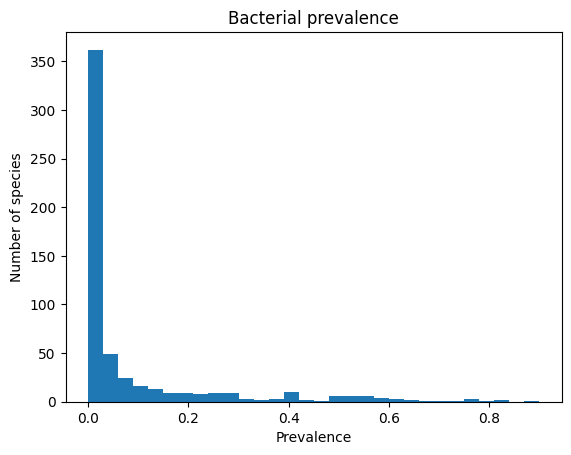

In [4]:
# filter bacteria that are not present in at least 10% of the patients
bacteria_df= data[bacteria_cols]
prevalence = (bacteria_df > 0).mean(axis=0)

plt.hist(prevalence, bins=30)
plt.xlabel("Prevalence")
plt.ylabel("Number of species")
plt.title("Bacterial prevalence")
plt.show()


In [5]:
#select threshold based on prevalence -> 10%
selected_bacteria = prevalence[prevalence > 0.10].index
bacteria_filtered = bacteria_df[selected_bacteria]

# how many bacteria columns were removed?
print(f"Original bacteria: {len(bacteria_cols)}")
print(f"Remaining bacteria: {len(selected_bacteria)}")
print(f"Removed bacteria: {len(bacteria_cols) - len(selected_bacteria)}")
print(list(selected_bacteria.unique()))

Original bacteria: 566
Remaining bacteria: 126
Removed bacteria: 440
['Bacteroides vulgatus', 'Bacteroides uniformis', 'Bacteroides thetaiotaomicron', 'Faecalibacterium prausnitzii', 'Roseburia faecis', 'Bacteroides caccae', 'Clostridium clostridioforme', 'Bacteroides fragilis', 'Fusicatenibacter saccharivorans', 'Flavonifractor plautii', 'Dialister invisus', 'Ruminococcus bicirculans', 'Blautia sp CAG 257', 'Ruminococcus gnavus', 'Dorea longicatena', 'Eubacterium hallii', 'Clostridium bolteae', 'Eubacterium sp CAG 38', 'Clostridium saccharolyticum', 'Intestinimonas butyriciproducens', 'Anaerostipes hadrus', 'Anaerotignum lactatifermentans', 'Ruthenibacterium lactatiformans', 'Lawsonibacter asaccharolyticus', 'Clostridium asparagiforme', 'Clostridium bolteae CAG 59', 'Clostridium symbiosum', 'Anaerotruncus colihominis', 'Agathobaculum butyriciproducens', 'Escherichia coli', 'Eisenbergiella massiliensis', 'Clostridium citroniae', 'Bacteroides stercoris', 'Monoglobus pectinilyticus', 'Al

In [6]:
############### CLR TRANSFORMATION ################
# data_filtered = pd.concat([metadata, bacteria_filtered], axis=1) -> IMPORTANT!!!!!!!!!

# Ensure all bacterial columns are numeric
bacteria_filtered = bacteria_filtered.apply(
    pd.to_numeric,
    errors="coerce"
)

# Check for missing or negative values
if bacteria_filtered.isna().any().any():
    raise ValueError("bacteria_filtered contains missing or non-numeric values.")

if (bacteria_filtered < 0).any().any():
    raise ValueError("CLR transformation cannot be applied to negative abundances.")

# Find the smallest positive abundance in the filtered dataset
positive_values = bacteria_filtered.to_numpy()
positive_values = positive_values[positive_values > 0]

if len(positive_values) == 0:
    raise ValueError("No positive bacterial abundances were found.")

minimum_positive = positive_values.min()

# Replace zeros with half of the smallest observed positive abundance
pseudocount = minimum_positive / 2

bacteria_with_pseudocount = bacteria_filtered.mask(
    bacteria_filtered == 0,
    pseudocount
)

# CLR transformation:
# log(x_ij) - mean(log(x_i)) for each sample i
log_bacteria = np.log(bacteria_with_pseudocount)

bacteria_clr = log_bacteria.subtract(
    log_bacteria.mean(axis=1),
    axis=0
)

print("Pseudocount:", pseudocount)
print("Original shape:", bacteria_filtered.shape)
print("CLR shape:", bacteria_clr.shape)

bacteria_clr.head()


Pseudocount: 7.5e-05
Original shape: (3387, 126)
CLR shape: (3387, 126)


,Bacteroides vulgatus,Bacteroides uniformis,Bacteroides thetaiotaomicron,Faecalibacterium prausnitzii,Roseburia faecis,Bacteroides caccae,Clostridium clostridioforme,Bacteroides fragilis,Fusicatenibacter saccharivorans,Flavonifractor plautii,...,Bacteroides massiliensis,Streptococcus parasanguinis,Ruminococcaceae bacterium D16,Veillonella sp T11011 6,Clostridium sp CAG 299,Eubacterium ventriosum,Bifidobacterium bifidum,Bifidobacterium pseudocatenulatum,Cutibacterium acnes,Coprococcus catus
0,11.275642,10.973324,9.448407,9.195984,9.142418,8.547916,8.047783,7.360410,7.171225,7.127637,...,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235
1,10.290180,11.139249,11.056703,8.790667,8.787438,8.615329,5.403633,10.598451,4.329918,8.104735,...,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297
2,9.544013,9.794746,8.355849,5.649234,5.610303,9.363196,8.218488,5.513449,6.208072,6.648385,...,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264
3,10.980918,10.712144,10.200370,7.604752,8.045569,7.751869,0.959015,7.819666,6.073697,8.195977,...,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832
4,10.432080,10.517945,8.992810,7.115643,7.322088,7.705074,5.870157,7.791002,5.700724,6.963381,...,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501


In [7]:
row_means = bacteria_clr.mean(axis=1)

print(row_means.describe())
print("Largest absolute row mean:", row_means.abs().max())

count    3.387000e+03
mean     1.075574e-14
std      2.718357e-15
min      1.677670e-15
25%      8.948750e-15
50%      1.057355e-14
75%      1.246269e-14
max      1.930026e-14
dtype: float64
Largest absolute row mean: 1.9300258040785262e-14


In [8]:
# Concat the metadata and bacteria_clr together
metadata = data.iloc[:, :data.columns.get_loc("fecalcal") + 1].copy()

data_clr = pd.concat(
    [metadata, bacteria_clr],
    axis=1
)

print(data_clr.shape)
data_clr.head()

(3387, 131)


,External ID,Participant ID,week_num,diagnosis,fecalcal,Bacteroides vulgatus,Bacteroides uniformis,Bacteroides thetaiotaomicron,Faecalibacterium prausnitzii,Roseburia faecis,...,Bacteroides massiliensis,Streptococcus parasanguinis,Ruminococcaceae bacterium D16,Veillonella sp T11011 6,Clostridium sp CAG 299,Eubacterium ventriosum,Bifidobacterium bifidum,Bifidobacterium pseudocatenulatum,Cutibacterium acnes,Coprococcus catus
0,CSM5FZ3N,C3001,0.0,Crohns Disease,193.89000,11.275642,10.973324,9.448407,9.195984,9.142418,...,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235,-1.968235
1,CSM5FZ4C,C3001,8.0,Crohns Disease,61.34000,10.290180,11.139249,11.056703,8.790667,8.787438,...,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297,-1.717297
2,CSM5MCVV,C3001,16.0,Crohns Disease,115.27000,9.544013,9.794746,8.355849,5.649234,5.610303,...,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264,-2.470264
3,CSM67UA2,C3001,28.0,Crohns Disease,23.20350,10.980918,10.712144,10.200370,7.604752,8.045569,...,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832,-2.119832
4,CSM79HGP,C3001,38.0,Crohns Disease,37.17836,10.432080,10.517945,8.992810,7.115643,7.322088,...,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501,-2.570501


In [9]:
################# TRAIN/TEST SPLIT ####################

# create a copy that treats crohns and UC has IBD
df = data_clr.copy()
print('Unique diagnosis values before binary transformation:')
print(df["diagnosis"].value_counts(dropna=False))

diagnosis_mapping = {
    "Crohns Disease": "IBD",
    "Ulcerative Colitis": "IBD",
    "Healthy": "Healthy"
}

df["diagnosis_binary"] = df["diagnosis"].map(diagnosis_mapping)
print('\nUnique diagnosis values after binary transformation:')
print(df["diagnosis_binary"].value_counts(dropna=False))

#Encode the target 
df['diagnosis_encoded']= df["diagnosis_binary"].map({
    'Healthy':0,
    'IBD': 1
})

print('\nShape of df after binary transformation and ecoding:')
print(df.shape)

# Get our feature columns
bacteria_clr_learning= bacteria_clr.columns.tolist()

#Split by participant ID
groups = df['Participant ID']
y= df['diagnosis_encoded']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.3,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X=df[bacteria_clr_learning],
        y=y,
        groups=groups
    )
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# Feature and targe
X_train = train_df[bacteria_clr_learning].copy()
X_test = test_df[bacteria_clr_learning].copy()

y_train = train_df["diagnosis_encoded"].copy()
y_test = test_df["diagnosis_encoded"].copy()

groups_train = train_df["Participant ID"].copy()
groups_test = test_df["Participant ID"].copy()

#Chesks
print('\nX_train and X_test shape:')
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining distribution:")
print(
    train_df["diagnosis_binary"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting distribution:")
print(
    test_df["diagnosis_binary"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

participant_overlap = (
    set(groups_train)
    & set(groups_test)
)

print("\nParticipant overlap:", participant_overlap)
assert len(participant_overlap) == 0

Unique diagnosis values before binary transformation:
diagnosis
Crohns Disease        1608
Ulcerative Colitis     913
Healthy                866
Name: count, dtype: int64

Unique diagnosis values after binary transformation:
diagnosis_binary
IBD        2521
Healthy     866
Name: count, dtype: int64

Shape of df after binary transformation and ecoding:
(3387, 133)

X_train and X_test shape:
X_train: (2486, 126)
X_test: (901, 126)

Training distribution:
diagnosis_binary
IBD        77.23
Healthy    22.77
Name: proportion, dtype: float64

Testing distribution:
diagnosis_binary
IBD        66.7
Healthy    33.3
Name: proportion, dtype: float64

Participant overlap: set()


In [10]:
############# MODELS IMPROVED #############
#Define tree-based models
models = {
    "Decision Tree": {
        "model": DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ),
        "params": {
            "max_depth": [3, 5, 10, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5, 10]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [200, 500],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2, 5],
            "max_features": ["sqrt", "log2", 0.5]
        }
    },

    "Extra Trees": {
        "model": ExtraTreesClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [200, 500],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2, 5],
            "max_features": ["sqrt", "log2", 0.5]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            random_state=42
        ),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [2, 3],
            "min_samples_leaf": [1, 5, 10],
            "subsample": [0.7, 1.0]
        }
    },

    "XGBoost" : {
        "model": XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [3, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 1.0],
            "colsample_bytree": [0.7, 1.0],
            "reg_lambda": [1, 5]
        }
    }
}

def nested_grouped_cv(
    X,
    y,
    groups,
    models,
    outer_splits=5,
    inner_splits=4,
    repeats=3,
    optimization_metric="roc_auc"
):
    all_results = []
    parameter_results = []

    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    groups = groups.reset_index(drop=True)

    for repeat in range(repeats):

        outer_cv = StratifiedGroupKFold(
            n_splits=outer_splits,
            shuffle=True,
            random_state=42 + repeat
        )

        for model_name, specification in models.items():

            print("\n" + "=" * 70)
            print(f"Repeat {repeat + 1}/{repeats} — {model_name}")
            print("=" * 70)

            for fold, (outer_train_idx, outer_valid_idx) in enumerate(
                outer_cv.split(X, y, groups),
                start=1
            ):

                X_outer_train = X.iloc[outer_train_idx]
                X_outer_valid = X.iloc[outer_valid_idx]

                y_outer_train = y.iloc[outer_train_idx]
                y_outer_valid = y.iloc[outer_valid_idx]

                groups_outer_train = groups.iloc[outer_train_idx]
                groups_outer_valid = groups.iloc[outer_valid_idx]

                # Confirm that no participant appears in both sets
                overlap = (
                    set(groups_outer_train)
                    & set(groups_outer_valid)
                )

                assert len(overlap) == 0, (
                    "Participant leakage detected in an outer fold."
                )

                inner_cv = StratifiedGroupKFold(
                    n_splits=inner_splits,
                    shuffle=True,
                    random_state=1000 + repeat
                )

                grid_search = GridSearchCV(
                    estimator=clone(specification["model"]),
                    param_grid=specification["params"],
                    scoring=optimization_metric,
                    cv=inner_cv,
                    n_jobs=-1,
                    refit=True,
                    return_train_score=False,
                    error_score="raise"
                )

                grid_search.fit(
                    X_outer_train,
                    y_outer_train,
                    groups=groups_outer_train
                )

                best_model = grid_search.best_estimator_

                y_pred = best_model.predict(X_outer_valid)

                if hasattr(best_model, "predict_proba"):
                    y_probability = best_model.predict_proba(
                        X_outer_valid
                    )[:, 1]

                elif hasattr(best_model, "decision_function"):
                    y_probability = best_model.decision_function(
                        X_outer_valid
                    )

                else:
                    y_probability = None

                fold_result = {
                    "Model": model_name,
                    "Repeat": repeat + 1,
                    "Fold": fold,
                    "Accuracy": accuracy_score(
                        y_outer_valid,
                        y_pred
                    ),
                    "Precision": precision_score(
                        y_outer_valid,
                        y_pred,
                        zero_division=0
                    ),
                    "Recall": recall_score(
                        y_outer_valid,
                        y_pred,
                        zero_division=0
                    ),
                    "Specificity": recall_score(
                        y_outer_valid,
                        y_pred,
                        pos_label=0,
                        zero_division=0
                    ),
                    "F1": f1_score(
                        y_outer_valid,
                        y_pred,
                        zero_division=0
                    ),
                    "ROC AUC": (
                        roc_auc_score(
                            y_outer_valid,
                            y_probability
                        )
                        if y_probability is not None
                        else np.nan
                    ),
                    "Inner best score": grid_search.best_score_,
                    "Training participants":
                        groups_outer_train.nunique(),
                    "Validation participants":
                        groups_outer_valid.nunique()
                }

                all_results.append(fold_result)

                parameter_results.append({
                    "Model": model_name,
                    "Repeat": repeat + 1,
                    "Fold": fold,
                    "Best parameters": grid_search.best_params_
                })

                print(
                    f"Fold {fold}: "
                    f"F1={fold_result['F1']:.3f}, "
                    f"Recall={fold_result['Recall']:.3f}, "
                    f"ROC AUC={fold_result['ROC AUC']:.3f}"
                )

    return (
        pd.DataFrame(all_results),
        pd.DataFrame(parameter_results)
    )


In [11]:
nested_results, nested_parameters = nested_grouped_cv(
    X=X_train,
    y=y_train,
    groups=groups_train,
    models=models,
    outer_splits=5,
    inner_splits=4,
    repeats=3,
    optimization_metric="roc_auc"
)


Repeat 1/3 — Decision Tree
Fold 1: F1=0.751, Recall=0.771, ROC AUC=0.323
Fold 2: F1=0.747, Recall=0.703, ROC AUC=0.537
Fold 3: F1=0.846, Recall=0.898, ROC AUC=0.546
Fold 4: F1=0.764, Recall=0.742, ROC AUC=0.523
Fold 5: F1=0.805, Recall=0.786, ROC AUC=0.644

Repeat 1/3 — Random Forest
Fold 1: F1=0.836, Recall=0.910, ROC AUC=0.578
Fold 2: F1=0.835, Recall=0.848, ROC AUC=0.608
Fold 3: F1=0.841, Recall=0.872, ROC AUC=0.449
Fold 4: F1=0.858, Recall=0.939, ROC AUC=0.635
Fold 5: F1=0.889, Recall=0.935, ROC AUC=0.781

Repeat 1/3 — Extra Trees
Fold 1: F1=0.846, Recall=0.920, ROC AUC=0.533
Fold 2: F1=0.813, Recall=0.801, ROC AUC=0.662
Fold 3: F1=0.797, Recall=0.779, ROC AUC=0.430
Fold 4: F1=0.799, Recall=0.803, ROC AUC=0.641
Fold 5: F1=0.882, Recall=0.982, ROC AUC=0.656

Repeat 1/3 — Gradient Boosting
Fold 1: F1=0.857, Recall=0.966, ROC AUC=0.549
Fold 2: F1=0.785, Recall=0.819, ROC AUC=0.502
Fold 3: F1=0.865, Recall=0.956, ROC AUC=0.466
Fold 4: F1=0.821, Recall=0.900, ROC AUC=0.522
Fold 5: F1=0

In [12]:
#Summarize performance
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC AUC"
]

summary = (
    nested_results
    .groupby("Model")[metric_columns]
    .agg(["mean", "std"])
)

summary

Accuracy           Precision              Recall            \
                       mean       std      mean       std      mean       std   
Model                                                                           
Decision Tree      0.601888  0.112477  0.776922  0.065969  0.678108  0.156713   
Extra Trees        0.746390  0.054224  0.817909  0.035166  0.867243  0.071299   
Gradient Boosting  0.737359  0.042645  0.784052  0.024504  0.911365  0.045710   
Random Forest      0.765924  0.034285  0.812497  0.028186  0.908582  0.041072   
XGBoost            0.755139  0.034324  0.786910  0.022786  0.938486  0.051877   

                  Specificity                  F1             ROC AUC  \
                         mean       std      mean       std      mean   
Model                                                                   
Decision Tree        0.341386  0.207783  0.715375  0.112284  0.501476   
Extra Trees          0.337960  0.170836  0.840023  0.037457  0.610052   
Gradient Boosting    0.145651  0.117557  0.842429  0.027766  0.566437   
Random Forest        0.280953  0.154515  0.857014  0.020658  0.624650   
XGBoost              0.133159  0.129309  0.855089  0.023319  0.565863   

                             
                        std  
Model                        
Decision Tree      0.133169  
Extra Trees        0.143101  
Gradient Boosting  0.122061  
Random Forest      0.129637  
XGBoost            0.103164

In [13]:
#Rank models numerically
ranking = (
    nested_results
    .groupby("Model")[metric_columns]
    .mean()
    .sort_values("ROC AUC", ascending=False)
)

ranking

,Accuracy,Precision,Recall,Specificity,F1,ROC AUC
Model,,,,,,
Random Forest,0.765924,0.812497,0.908582,0.280953,0.857014,0.624650
Extra Trees,0.746390,0.817909,0.867243,0.337960,0.840023,0.610052
Gradient Boosting,0.737359,0.784052,0.911365,0.145651,0.842429,0.566437
XGBoost,0.755139,0.786910,0.938486,0.133159,0.855089,0.565863
Decision Tree,0.601888,0.776922,0.678108,0.341386,0.715375,0.501476


In [14]:
#Inspect hyperparameters selected most often
for model_name in nested_parameters["Model"].unique():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    model_parameters = nested_parameters.loc[
        nested_parameters["Model"] == model_name,
        "Best parameters"
    ]

    print(model_parameters.value_counts().head(10))


Decision Tree
Best parameters
{'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}       2
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}      1
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}     1
{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}      1
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}        1
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}     1
{'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}    1
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}       1
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}        1
{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}        1
Name: count, dtype: int64

Random Forest
Best parameters
{'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}       3
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 

In [15]:
#Select the best model
mean_performance = (
    nested_results
    .groupby("Model")[metric_columns]
    .mean()
    .sort_values("ROC AUC", ascending=False)
)

best_model_name = mean_performance.index[0]

print("Best model:", best_model_name)
print(mean_performance.loc[best_model_name])

Best model: Random Forest
Accuracy       0.765924
Precision      0.812497
Recall         0.908582
Specificity    0.280953
F1             0.857014
ROC AUC        0.624650
Name: Random Forest, dtype: float64


In [16]:
#Tune the best model on the entire training data
selected_specification = models[best_model_name]

final_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

final_search = GridSearchCV(
    estimator=clone(selected_specification["model"]),
    param_grid=selected_specification["params"],
    scoring="roc_auc",
    cv=final_cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

final_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

final_model = final_search.best_estimator_

print("Selected model:", best_model_name)
print("Best parameters:", final_search.best_params_)
print("Best grouped CV ROC AUC:", final_search.best_score_)

Selected model: Random Forest
Best parameters: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}
Best grouped CV ROC AUC: 0.6190538981698729


In [17]:
# Evaluate on the test data
y_test_pred = final_model.predict(X_test)

if hasattr(final_model, "predict_proba"):
    y_test_probability = final_model.predict_proba(X_test)[:, 1]
else:
    y_test_probability = final_model.decision_function(X_test)

# Calculate the metrics on the test set
test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "Specificity",
        "F1",
        "ROC AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_test_pred),

        precision_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        recall_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        recall_score(
            y_test,
            y_test_pred,
            pos_label=0,
            zero_division=0
        ),

        f1_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        roc_auc_score(
            y_test,
            y_test_probability
        )
    ]
})

test_results

,Metric,Value
0,Accuracy,0.740289
1,Precision,0.739244
2,Recall / Sensitivity,0.943428
3,Specificity,0.333333
4,F1,0.828947
5,ROC AUC,0.707393


In [18]:
# Print classification report
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Healthy", "IBD"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Healthy       0.75      0.33      0.46       300
         IBD       0.74      0.94      0.83       601

    accuracy                           0.74       901
   macro avg       0.74      0.64      0.64       901
weighted avg       0.74      0.74      0.71       901



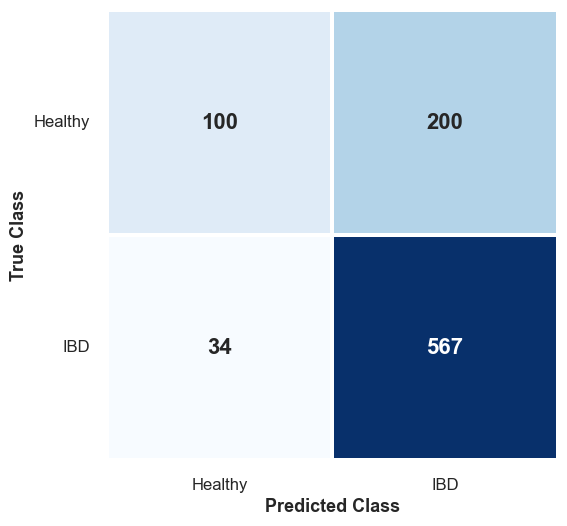

In [35]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1.5,
    linecolor="white",
    square=True,
    xticklabels=["Healthy", "IBD"],
    yticklabels=["Healthy", "IBD"],
    annot_kws={"fontsize":16, "fontweight":"bold"}
)

plt.xlabel("Predicted Class", fontsize=13, fontweight="bold")
plt.ylabel("True Class", fontsize=13, fontweight="bold")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=600)
plt.show()

In [20]:
# Compare CV and Test results
cv_mean = (
    nested_results
    .groupby("Model")[metric_columns]
    .mean()
    .loc[best_model_name]
)

comparison = pd.DataFrame({
    "Metric": metric_columns,
    "Nested CV mean": [
        cv_mean["Accuracy"],
        cv_mean["Precision"],
        cv_mean["Recall"],
        cv_mean["Specificity"],
        cv_mean["F1"],
        cv_mean["ROC AUC"]
    ],
    "Final test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        recall_score(
            y_test,
            y_test_pred,
            pos_label=0,
            zero_division=0
        ),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_probability)
    ]
})

comparison

,Metric,Nested CV mean,Final test
0,Accuracy,0.765924,0.740289
1,Precision,0.812497,0.739244
2,Recall,0.908582,0.943428
3,Specificity,0.280953,0.333333
4,F1,0.857014,0.828947
5,ROC AUC,0.624650,0.707393


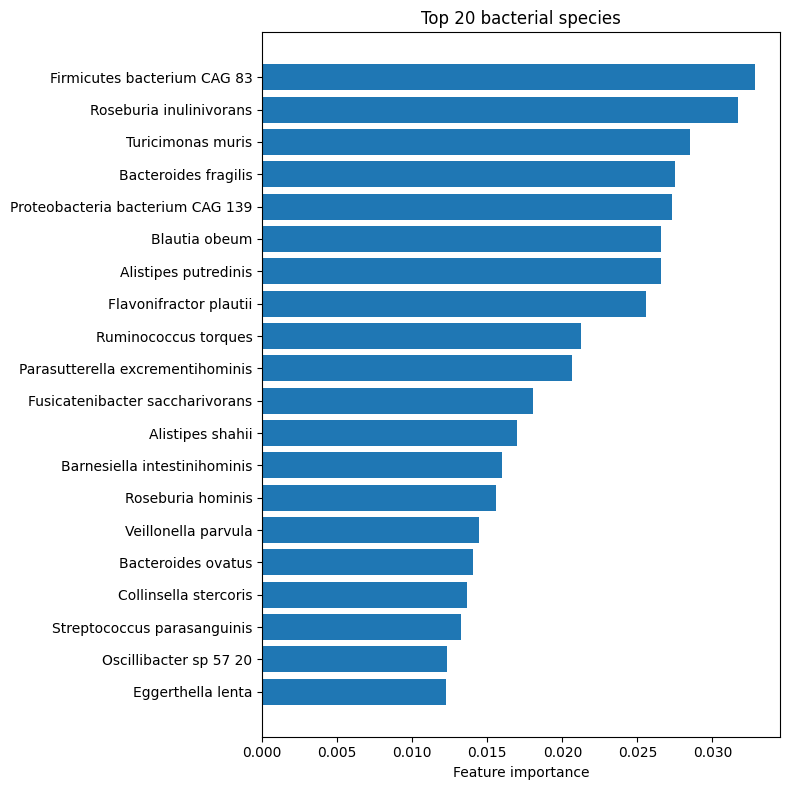

In [21]:
################ MOST RELEVANT FEATURES ################

#Using Random Forest Feature Importance
importance = pd.DataFrame({
    "Bacteria": X_train.columns,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

top20 = importance.head(20)

plt.figure(figsize=(8,8))

plt.barh(
    top20["Bacteria"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature importance")

plt.title("Top 20 bacterial species")

plt.tight_layout()

plt.show()

In [22]:
# Permutation Importance
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="f1"
)

perm_importance = pd.DataFrame({

    "Bacteria": X_test.columns,

    "Importance": perm.importances_mean,

    "Std": perm.importances_std

})

perm_importance = perm_importance.sort_values(
    "Importance",
    ascending=False
)

perm_importance.head(20)

,Bacteria,Importance,Std
34,Alistipes putredinis,0.007989,0.002751
80,Proteobacteria bacterium CAG 139,0.005647,0.002964
92,Firmicutes bacterium CAG 83,0.004069,0.002432
42,Bacteroides ovatus,0.003474,0.001522
89,Coprococcus comes,0.001738,0.001269
30,Eisenbergiella massiliensis,0.001346,0.000954
20,Anaerostipes hadrus,0.001080,0.000948
5,Bacteroides caccae,0.001000,0.000589
61,Collinsella aerofaciens,0.000863,0.000929
70,Barnesiella intestinihominis,0.000852,0.001113


c:\Users\raque\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape: (901, 126)
SHAP shape: (901, 126, 2)
Classes: [0 1]


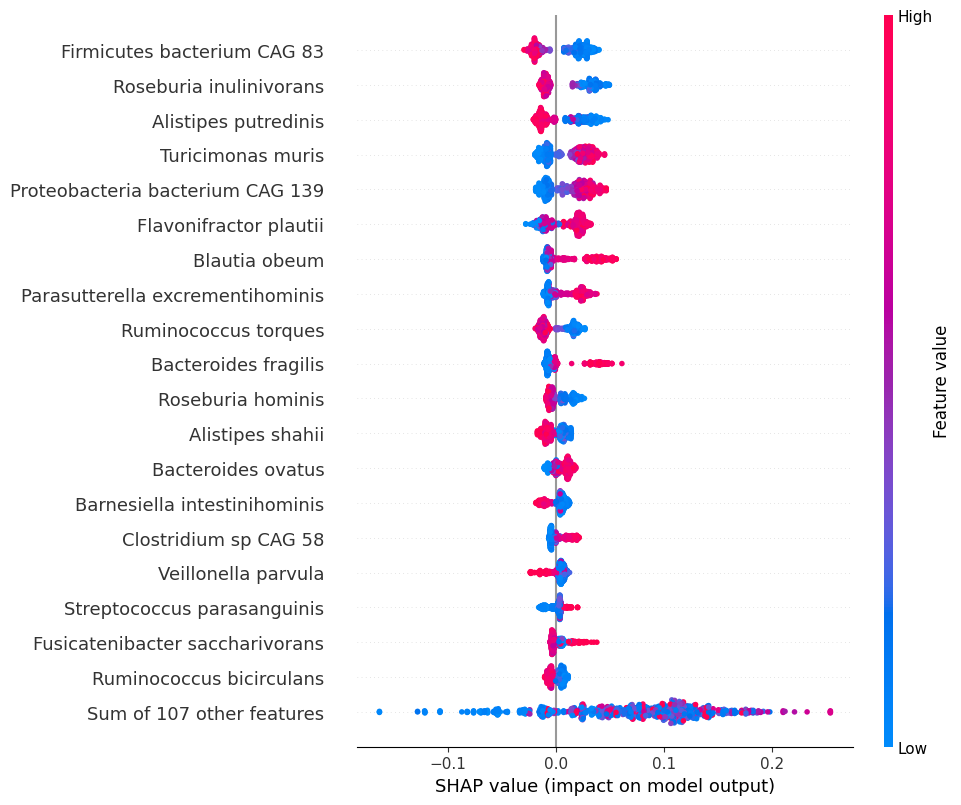

In [23]:
# SHAP importance
import shap

# Ensure the feature columns are in the same order used during training
X_explain = X_test[X_train.columns].copy()

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_explain)

print("Input shape:", X_explain.shape)
print("SHAP shape:", shap_values.values.shape)
print("Classes:", final_model.classes_)

if shap_values.values.ndim == 3:
    # Our case -> explanation for IBD = 1
    ibd_class_index = list(final_model.classes_).index(1)
    shap_values_plot = shap_values[:, :, ibd_class_index]

elif shap_values.values.ndim == 2:
    # For SHAP versions that return one matrix directly
    shap_values_plot = shap_values

else:
    raise ValueError(
        f"Unexpected SHAP dimensions: {shap_values.values.shape}"
    )

assert shap_values_plot.values.shape == X_explain.shape

shap.plots.beeswarm(
    shap_values_plot,
    max_display=20
)


                             Bacteria  Mean_SHAP
92        Firmicutes bacterium CAG 83   0.021416
40            Roseburia inulinivorans   0.020055
34               Alistipes putredinis   0.019352
79                  Turicimonas muris   0.018673
80   Proteobacteria bacterium CAG 139   0.018593
9              Flavonifractor plautii   0.016787
71                      Blautia obeum   0.015730
74   Parasutterella excrementihominis   0.013706
56               Ruminococcus torques   0.013506
7                Bacteroides fragilis   0.010983
36                  Roseburia hominis   0.008350
110                  Alistipes shahii   0.007917
42                 Bacteroides ovatus   0.007348
70       Barnesiella intestinihominis   0.007085
77              Clostridium sp CAG 58   0.006306
102               Veillonella parvula   0.005622
117       Streptococcus parasanguinis   0.005481
8     Fusicatenibacter saccharivorans   0.005320
11           Ruminococcus bicirculans   0.005235
72              Coll

C:\Users\raque\AppData\Local\Temp\ipykernel_31924\1785372844.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\raque\AppData\Local\Temp\ipykernel_31924\1785372844.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\raque\AppData\Local\Temp\ipykernel_31924\1785372844.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\raque\AppData\Local\Temp\ipykernel_31924\1785372844.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

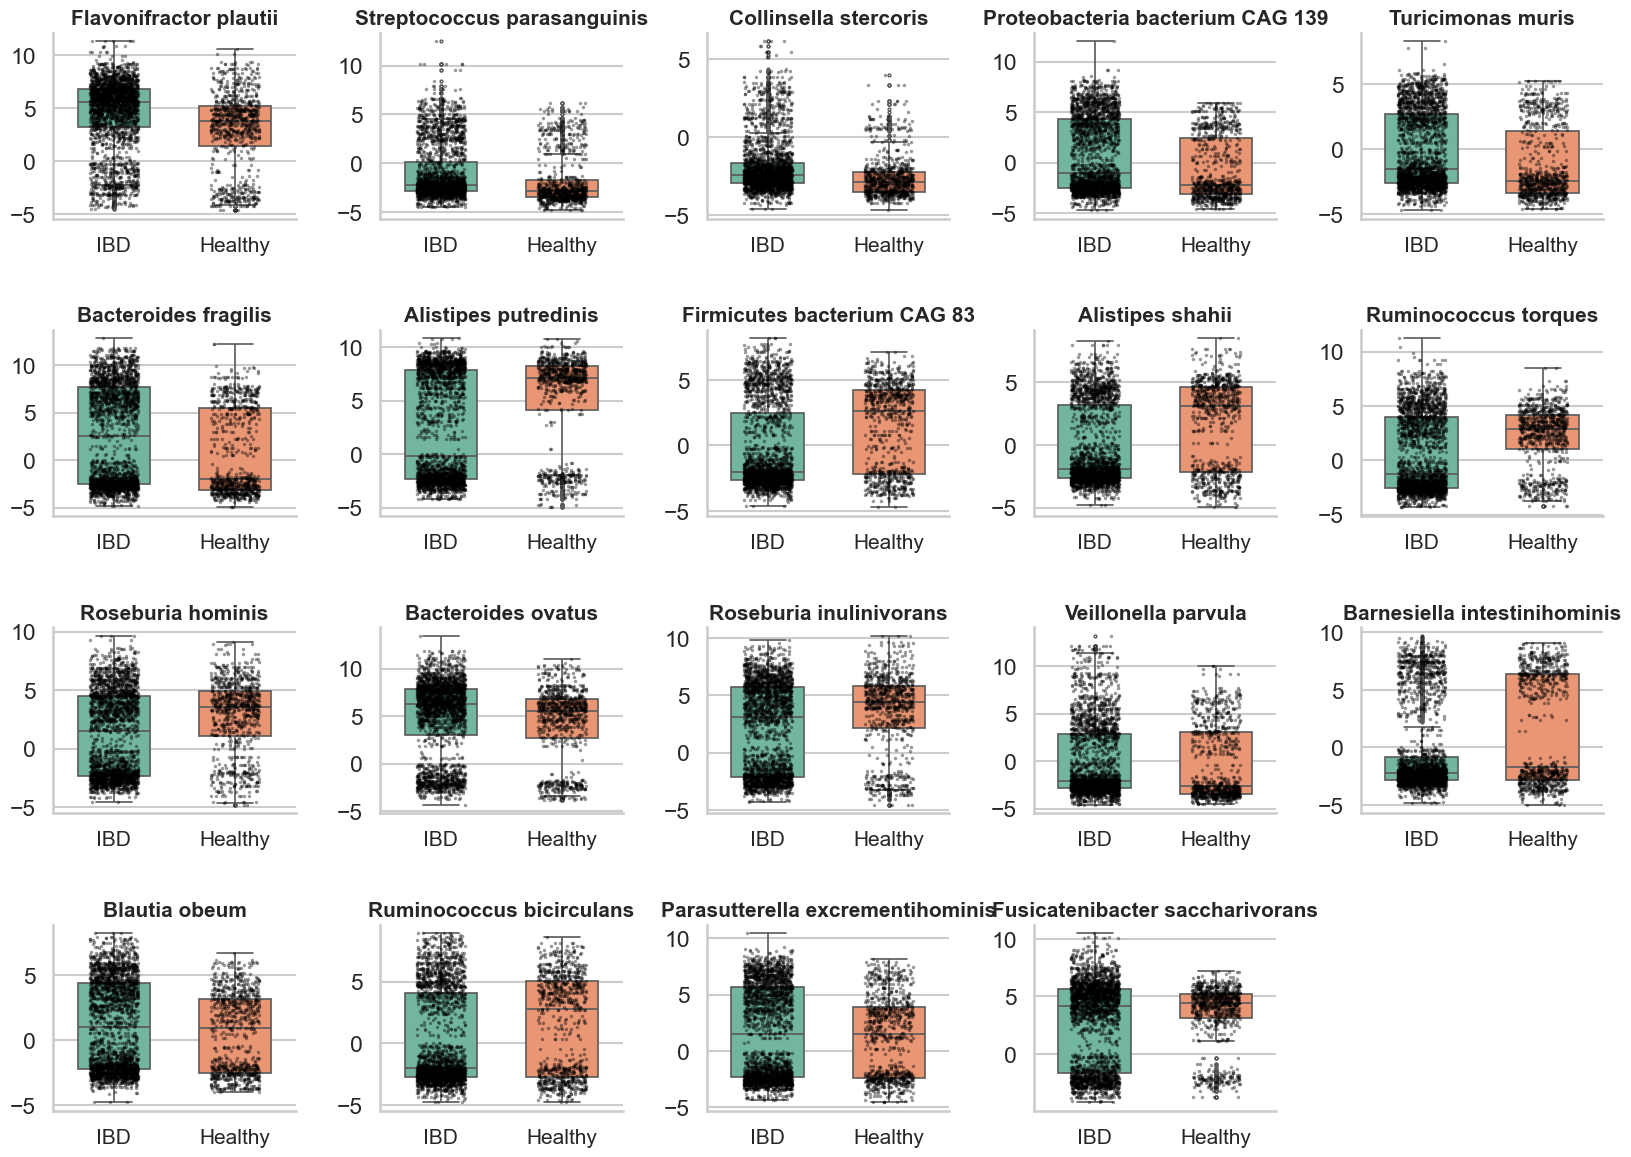

In [24]:
# Statistical significance
# Mean absolute SHAP value for each bacterium

ibd_index = list(final_model.classes_).index(1)
shap_values_ibd = shap_values[:, :, ibd_index]

mean_shap = np.abs(shap_values_ibd.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Bacteria": X_test.columns,
    "Mean_SHAP": mean_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_SHAP",
    ascending=False
)

top20 = shap_importance.head(20)

print(top20)

#Build dataframe for plotting
plot_df = df.copy()

# Make sure the diagnosis labels are the binary ones
plot_df["Diagnosis"] = plot_df["diagnosis_binary"]

# Man whitney test
from scipy.stats import mannwhitneyu

results = []

for bacteria in top20["Bacteria"]:

    healthy = plot_df.loc[
        plot_df["Diagnosis"] == "Healthy",
        bacteria
    ]

    ibd = plot_df.loc[
        plot_df["Diagnosis"] == "IBD",
        bacteria
    ]

    statistic, p = mannwhitneyu(
        healthy,
        ibd,
        alternative="two-sided"
    )

    results.append({
        "Bacteria": bacteria,
        "p-value": p,
        "Median Healthy": healthy.median(),
        "Median IBD": ibd.median()
    })

results = pd.DataFrame(results)
results = results.sort_values("p-value")

results

# Correct for multiple testing
from statsmodels.stats.multitest import multipletests

results["Adjusted p"] = multipletests(
    results["p-value"],
    method="fdr_bh"
)[1]

results = results.sort_values("Adjusted p")

results

significant = results[
    results["Adjusted p"] < 0.05
]

print(significant)

# plot significant bacteria
# Style
sns.set_theme(style="whitegrid", context="talk")

bacteria_list = significant["Bacteria"]

ncols = 5
nrows = 4
plots_per_fig = ncols * nrows

for start in range(0, len(bacteria_list), plots_per_fig):

    subset = bacteria_list[start:start + plots_per_fig]

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(20, 14),
    )
    
    fig.subplots_adjust(hspace=0.6, wspace=0.35)

    axes = axes.flatten()

    for ax, bacteria in zip(axes, subset):

        sns.boxplot(
            data=plot_df,
            x="Diagnosis",
            y=bacteria,
            palette="Set2",
            width=0.6,
            linewidth=1.2,
            fliersize=2,
            ax=ax
        )

        sns.stripplot(
            data=plot_df,
            x="Diagnosis",
            y=bacteria,
            color="black",
            alpha=0.4,
            size=2.5,
            jitter=0.2,
            ax=ax
        )

        ax.set_title(bacteria, fontsize=15, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize= 15)

        sns.despine(ax=ax)

    # Remove unused axes
    for ax in axes[len(subset):]:
        fig.delaxes(ax)

    plt.show()